# **Tutorial 3** $\cdot$ Counterfactual Explanations

> **Abstract.** To be written at the end.


**💾 Dataset.** This notebook will make use of the [AqSolDB](https://www.kaggle.com/datasets/sorkun/aqsoldb-a-curated-aqueous-solubility-dataset) 
dataset introduced by [Sorkun et al.](https://www.nature.com/articles/s41597-019-0151-1). Its a curated dataset consisting of roughly ten thousand 
small molecules annotated with experimentally determined [water solubility](https://en.wikipedia.org/wiki/Solubility) values. These target annotations were curated and consolidated from 
various sources throughout the literature. Due to it's experimental nature and the presence of measurement noise, it is important to note that 
it is impossible to achieve perfect prediction accuracy for this dataset. Based on results from the literature, the practical limit to the 
performance likely is a predictivity (R² score) in the range between 0.86 and 0.89.

**📦 Packages.** Packages used in this notebook include:
- [RDKit](https://www.rdkit.org/docs/index.html) Cheminformatics framework for processing of SMILES strings and molecular manipulation.
- [Pandas](https://pandas.pydata.org/docs/index.html) for data representation and processing.
- [Pytorch](https://docs.pytorch.org/docs/stable/index.html) and [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) for the training of neural network models.
- [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/) framework for the construction, training and explanation of graph neural network (GNN)-based property prediction models.
- [exmol](https://github.com/ur-whitelab/exmol) for generating counterfactual molecular explanations using the MMACE method.

In [1]:
import os
import random
import warnings

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import rdkit.Chem as Chem
import lightning.pytorch as pl
import torch.nn as nn
import torch.nn.functional as F
from rich.pretty import pprint
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torchmetrics import MeanSquaredError, R2Score

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

from xai_chem_review import load_dataset_aqsoldb

/media/ssd/Programming/xai_chem_review/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The `load_dataset_aqsoldb` function loads and returns the AqSolDB dataset into a pandas `DataFrame` object. Each molecule is represented as a [SMILES](https://en.wikipedia.org/wiki/Simplified_Molecular_Input_Line_Entry_System) string with a continuous water solubility value (logS).

In [2]:
data_frame: pd.DataFrame = load_dataset_aqsoldb()
print(f'Loaded dataset with {data_frame.shape[0]} rows')
print(f'Solubility statistics:')
print(data_frame['solubility'].describe())
data_frame.head()

Loaded dataset with 11024 rows
Solubility statistics:
count    11024.000000
mean        -2.880460
std          2.343010
min        -13.171900
25%         -4.286934
50%         -2.600300
75%         -1.228457
max          2.137682
Name: solubility, dtype: float64


,index,ID,smiles,InChIKey,solubility,split
0,0,A-10,Cc1cccc(C=C)c1,JZHGRUMIRATHIU-UHFFFAOYSA-N,-3.123150,1
1,1,A-100,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,ODJUOZPKKHIEOZ-UHFFFAOYSA-N,-4.952869,1
2,2,A-1000,O=C1CCCCCCCCCOCCCCCO1,MKEIDVFLAWJKMY-UHFFFAOYSA-N,-3.883849,1
3,3,A-1002,CCCCCCCCCCC(C)CCCCCCCC,FFVPRSKCTDQLBP-UHFFFAOYSA-N,-6.451105,1
4,4,A-1003,NC(=O)N=NC(N)=O,XOZUGNYVDXMRKW-UHFFFAOYSA-N,-3.546243,1


In [3]:
data_frame['mol'] = data_frame['smiles'].apply(Chem.MolFromSmiles)
data_frame = data_frame.dropna(subset=['mol']).reset_index(drop=True)
print(f'After mol conversion {data_frame.shape[0]} rows remaining')

After mol conversion 11022 rows remaining


## **3.1** $\cdot$ 💡 Counterfactual Explanations

The previous tutorials have introduced *attributional* explanation methods &mdash; techniques that reveal which parts of the input are most important for a model's prediction. While these methods answer the question "what did the model focus on?", they don't directly address a more intuitive question that practitioners often ask: "what would need to change to get a different prediction?"

*Counterfactual explanations* answer exactly this question. Rather than highlighting important features or substructures, counterfactual methods identify the minimal modifications to an input that would change the model's prediction to a desired outcome. In other words, they provide "what-if" scenarios that reveal the decision boundaries learned by the model. This paradigm shift from attribution to intervention offers a fundamentally different perspective on model interpretability.

**Relevance to Molecular Property Prediction.** In the context of drug discovery and molecular design, counterfactual explanations are particularly valuable. When a model predicts that a compound has poor water solubility, a counterfactual explanation would show the smallest structural modifications that would improve the predicted solubility. Unlike attributional methods that might highlight "the aromatic ring is important", counterfactuals provide *actionable* insights like "replacing this methyl group with a hydroxyl group would increase solubility by 1.5 logS units". This makes counterfactual explanations directly applicable to lead optimization and molecular design workflows.

**Comparison to Attributional Methods.** The key distinction between counterfactual and attributional explanations lies in their output format and intended use:

- **Attributional methods** (SHAP, LIME, GNNExplainer) produce importance scores over input features or substructures, answering "what matters?"
- **Counterfactual methods** produce alternative molecular structures with different predictions, answering "what would need to change?"

Both approaches are complementary. Attributional explanations help understand the model's reasoning process, while counterfactuals provide concrete suggestions for molecular modifications. In practice, the structural changes suggested by counterfactuals often align with the features identified as important by attributional methods &mdash; but presented in a more directly actionable format.

**Challenges in Molecular Counterfactuals.** Generating counterfactual explanations for molecules presents unique challenges compared to tabular or image data. The modifications must produce *chemically valid* structures that respect valence rules, aromaticity constraints, and synthetic accessibility. Simply perturbing input features (as one might do with tabular data) is not sufficient &mdash; the resulting molecules must be realistic compounds that could potentially be synthesized and tested. This requirement has led to the development of specialized algorithms for exploring chemical space around a given molecule.

## **3.2** $\cdot$ 📚 *Model Agnostic Counterfactual Compounds* (`MMACE`)

The first example method from the literature is the *Model Agnostic Counterfactual Compounds (MMACE)* approach, implemented in the [exmol](https://github.com/ur-whitelab/exmol) package by [White et al.](https://doi.org/10.26434/chemrxiv.13646574). This method leverages the **STONED** (Synthetic Transformations of Nearby Edges and Discrete neighborhoods) algorithm to systematically explore the chemical space around a given molecule and identify counterfactual examples.

**Core Methodology.** MMACE works by:
1. **Molecular Transformation**: Using STONED to generate chemically valid variants of the input molecule through systematic bond modifications, atom replacements, and structural rearrangements
2. **Model Evaluation**: Testing each generated variant with the target model to identify those with different predictions
3. **Similarity Ranking**: Ranking the counterfactual candidates by their structural similarity to the original molecule
4. **Selection**: Choosing the most similar counterfactuals that achieve the desired prediction change

**Implementation.** The `exmol` package provides a streamlined interface for generating molecular counterfactuals. The package is model-agnostic, meaning it can work with any molecular property prediction model that accepts SMILES strings as input and returns predictions. This flexibility makes it applicable to a wide range of machine learning models, from simple linear classifiers to complex neural networks.

### Graph Neural Network Model

Before generating counterfactual explanations, we need to train a molecular property prediction model. For this tutorial, we'll use a Graph Neural Network (GNN) to predict water solubility directly from molecular graph structures. This approach allows us to demonstrate how counterfactual explanations can be applied to sophisticated graph-based models for regression tasks.

We'll reuse the graph processing functions from the second tutorial, which convert molecules into graph representations suitable for GNN training. This approach provides direct access to molecular structure information, making it particularly suitable for understanding structural changes in counterfactual explanations for solubility prediction.

In [4]:
# --- Atom and Bond Encoding Functions ---
# These functions convert RDKit atom and bond objects into fixed-size numeric vectors
# suitable for use as node and edge features in a graph neural network.

def encode_atom(atom: Chem.Atom,
                supported_atoms: list[str] = ['C', 'N', 'O', 'S', 'P', 'Cl', 'Br', 'F'],
                ) -> np.ndarray:
    """
    Encodes a given RDKit atom object into a fixed-size vector representation of its properties,
    including a one-hot encoding of the atom type, valence information, and formal charge.

    :param atom: The RDKit Atom object to be converted.
    :param supported_atoms: A list of atom symbols supported for one-hot encoding. Atoms not
        in this list are marked as unknown.

    :returns: A numpy array of shape (n_features,) containing the encoded atom properties.
    """
    # One-hot encoding of atom type
    atom_one_hot = np.zeros(len(supported_atoms), dtype=np.float32)
    if atom.GetSymbol() in supported_atoms:
        atom_one_hot[supported_atoms.index(atom.GetSymbol())] = 1.0

    atom_unknown = float(atom.GetSymbol() not in supported_atoms)
    atom_valence = atom.GetTotalValence()
    atom_valence_implicit = atom.GetImplicitValence()
    atom_charge = atom.GetFormalCharge()

    return np.array([
        *atom_one_hot,
        atom_unknown,
        atom_valence,
        atom_valence_implicit,
        atom_charge,
    ], dtype=np.float32)


def encode_bond(bond: Chem.Bond,
                supported_bond_types: list[int] = [
                    Chem.BondType.SINGLE,
                    Chem.BondType.DOUBLE,
                    Chem.BondType.TRIPLE,
                ],
                ) -> np.ndarray:
    """
    Encodes a given RDKit bond object into a fixed-size vector representation of its properties,
    including a one-hot encoding of the bond type, stereo configuration, and aromaticity.

    :param bond: The RDKit Bond object to be converted.
    :param supported_bond_types: A list of bond types supported for one-hot encoding.

    :returns: A numpy array of shape (n_features,) containing the encoded bond properties.
    """
    # One-hot encoding of bond type
    bond_type_one_hot = np.zeros(len(supported_bond_types), dtype=np.float32)
    if bond.GetBondType() in supported_bond_types:
        bond_type_one_hot[supported_bond_types.index(bond.GetBondType())] = 1.0

    bond_unknown = float(bond.GetBondType() not in supported_bond_types)
    bond_stereo = bond.GetStereo()
    bond_aromatic = float(bond.GetIsAromatic())

    return np.array([
        *bond_type_one_hot,
        bond_unknown,
        bond_stereo,
        bond_aromatic,
    ], dtype=np.float32)


# --- Graph Conversion Functions ---
# These functions handle the conversion between SMILES strings, networkx graphs,
# and PyTorch Geometric Data objects.

def graph_from_smiles(smiles: str,
                      atom_encoder: callable = encode_atom,
                      bond_encoder: callable = encode_bond,
                      ) -> nx.Graph:
    """
    Converts a SMILES string to a networkx Graph representation where nodes represent
    atoms and edges represent bonds, each annotated with numeric feature vectors.

    :param smiles: The SMILES string of the molecule to be converted.
    :param atom_encoder: A callable that encodes an RDKit Atom into a feature vector.
    :param bond_encoder: A callable that encodes an RDKit Bond into a feature vector.

    :returns: A networkx Graph object, or None if the SMILES string is invalid.
    """
    mol: Chem.Mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    g: nx.Graph = nx.Graph()

    # Add atoms as nodes with encoded features
    for atom in mol.GetAtoms():
        node_attributes: np.ndarray = atom_encoder(atom)
        g.add_node(
            atom.GetIdx(),
            node_index=atom.GetIdx(),
            node_atom=atom.GetSymbol(),
            node_attributes=node_attributes
        )

    # Add bonds as edges with encoded features
    for bond in mol.GetBonds():
        edge_attributes: np.ndarray = bond_encoder(bond)
        g.add_edge(
            bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(),
            edge_type=bond.GetBondType(),
            edge_attributes=edge_attributes,
        )

    return g


def data_from_graph(graph: nx.Graph) -> Data:
    """
    Converts a networkx Graph to a PyTorch Geometric Data object suitable for GNN training.

    :param graph: A networkx Graph with 'node_attributes' and 'edge_attributes' annotations.

    :returns: A PyTorch Geometric Data object, or None if the input graph is None.
    """
    if graph is None:
        return None

    # Extract node features
    node_attributes = np.array([
        data['node_attributes'].tolist() for _, data in graph.nodes(data=True)
    ])

    # Extract edge indices and features
    edge_indices = np.array([
        (u, v) for (u, v) in graph.edges()
    ])
    edge_attributes = np.array([
        data['edge_attributes'].tolist()
        for _, _, data in graph.edges(data=True)
    ])

    # Construct the Data object
    data = Data(
        x=torch.tensor(node_attributes, dtype=torch.float32),
        edge_index=torch.tensor(edge_indices.T, dtype=torch.long) if len(edge_indices) > 0 else torch.empty((2, 0), dtype=torch.long),
        edge_attr=torch.tensor(edge_attributes, dtype=torch.float32) if len(edge_attributes) > 0 else torch.empty((0, 6), dtype=torch.float32),
    )

    # Attach target labels if present in the graph
    if graph.graph.get('graph_labels') is not None:
        data.y = torch.tensor(graph.graph['graph_labels'], dtype=torch.float32)

    return data


# --- Example usage ---

test_smiles = 'CCc1ccc2nc(S(N)(=O)=O)sc2c1'
test_graph = graph_from_smiles(test_smiles)
test_data = data_from_graph(test_graph)
print(f'Test molecule converted to graph with {test_data.x.shape[0]} nodes and {test_data.edge_index.shape[1]} edges')

Test molecule converted to graph with 15 nodes and 16 edges


Now we can convert all molecules in our dataset to graph representations and prepare them for GNN training:

In [5]:
# --- Converting molecules to graph representations ---
# Apply the graph_from_smiles function to each molecule in the dataset.

data_frame['graph'] = data_frame['smiles'].apply(graph_from_smiles)

# Remove molecules that couldn't be converted to valid graphs
data_frame = data_frame.dropna(subset=['graph']).reset_index(drop=True)

# --- Attaching target labels to graphs ---
# The target solubility values need to be attached to the graph objects for PyG Data conversion.

for idx, row in data_frame.iterrows():
    if row['graph'] is not None:
        row['graph'].graph['graph_labels'] = row['solubility']

print(f'Dataset after graph conversion: {len(data_frame)} molecules')
data_frame[['smiles', 'solubility']].head()

Dataset after graph conversion: 11022 molecules


,smiles,solubility
0,Cc1cccc(C=C)c1,-3.123150
1,Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2,-4.952869
2,O=C1CCCCCCCCCOCCCCCO1,-3.883849
3,CCCCCCCCCCC(C)CCCCCCCC,-6.451105
4,NC(=O)N=NC(N)=O,-3.546243


### Model Training

Next, we'll train a Graph Neural Network regressor to predict water solubility based on molecular graph structure. This model will serve as our "black-box" predictor for which we'll generate counterfactual explanations.

In [6]:
# --- Train-test split ---
# Randomly partition the dataset into training and test sets using an 80/20 split.

indices = list(range(len(data_frame)))
random.shuffle(indices)

n_train = int(0.8 * len(indices))
train_indices = indices[:n_train]
test_indices = indices[n_train:]

print(f'Train set: {len(train_indices)} molecules')
print(f'Test set: {len(test_indices)} molecules')

# --- Creating PyTorch Geometric Data objects ---

data_list_train = [
    data_from_graph(data_frame.iloc[idx]['graph'])
    for idx in train_indices
    if data_frame.iloc[idx]['graph'] is not None
]
data_list_test = [
    data_from_graph(data_frame.iloc[idx]['graph'])
    for idx in test_indices
    if data_frame.iloc[idx]['graph'] is not None
]

# --- Creating DataLoaders ---

loader_train = DataLoader(data_list_train, batch_size=32, shuffle=True, num_workers=4)
loader_test = DataLoader(data_list_test, batch_size=32, shuffle=False)

Train set: 8817 molecules
Test set: 2205 molecules


In [7]:
from torch_geometric.nn.conv import GINEConv
from torch_geometric.nn.aggr import SumAggregation


class SolubilityGNN(pl.LightningModule):
    """
    Graph Neural Network regressor for predicting water solubility from molecular graphs.
    Uses GINE (Graph Isomorphism Network with Edge features) convolutional layers followed
    by global sum pooling and dense layers for graph-level regression.
    
    :param input_dim: The number of input node features.
    :param edge_dim: The number of input edge features.
    :param hidden_units: List of hidden layer sizes for the graph convolutions.
    :param dense_units: List of hidden layer sizes for the dense prediction network.
    :param output_dim: The number of output features (1 for single-target regression).
    :param learning_rate: Learning rate for the Adam optimizer.
    """
    
    def __init__(self, 
                 input_dim: int,
                 edge_dim: int,
                 hidden_units: list[int] = [128, 128, 128],
                 dense_units: list[int] = [64, 32],
                 output_dim: int = 1,
                 learning_rate: float = 1e-4,
                 ):
        super().__init__()
        self.save_hyperparameters()
        
        self.input_dim = input_dim
        self.edge_dim = edge_dim
        self.hidden_units = hidden_units
        self.dense_units = dense_units
        self.output_dim = output_dim
        self.learning_rate = learning_rate
        
        # --- Embedding layers ---
        # Map input features to the hidden dimension
        self.node_embedding = nn.Linear(input_dim, hidden_units[0])
        self.edge_embedding = nn.Linear(edge_dim, 64)
        
        # --- Graph convolutional layers ---
        # Build GINE layers with internal MLPs for message passing
        self.conv_layers = nn.ModuleList()
        prev_units = hidden_units[0]
        for units in hidden_units:
            mlp = nn.Sequential(
                nn.Linear(prev_units, units),
                nn.BatchNorm1d(units),
                nn.ReLU(),
                nn.Linear(units, units),
                nn.BatchNorm1d(units),
                nn.ReLU()
            )
            conv = GINEConv(nn=mlp, edge_dim=64)
            self.conv_layers.append(conv)
            prev_units = units
            
        # --- Global pooling ---
        self.pooling = SumAggregation()
        
        # --- Dense prediction layers ---
        self.dense_layers = nn.ModuleList()
        for units in dense_units:
            layer = nn.Sequential(
                nn.Linear(prev_units, units),
                nn.BatchNorm1d(units),
                nn.ReLU()
            )
            self.dense_layers.append(layer)
            prev_units = units
            
        self.output_layer = nn.Linear(prev_units, output_dim)
        
        # --- Loss and metrics ---
        self.criterion = nn.MSELoss()
        self.mse = MeanSquaredError()
        self.r2 = R2Score()
        
    def forward(self, x, edge_index, edge_attr, batch):
        """
        Forward pass through the GNN.
        
        :param x: Node feature tensor of shape (num_nodes, input_dim).
        :param edge_index: Edge index tensor of shape (2, num_edges).
        :param edge_attr: Edge attribute tensor of shape (num_edges, edge_dim).
        :param batch: Batch assignment tensor for graph-level pooling.
        
        :returns: Prediction tensor of shape (batch_size, output_dim).
        """
        # Embed node and edge features
        node_emb = self.node_embedding(x)
        edge_emb = self.edge_embedding(edge_attr)
        
        # Apply graph convolutions
        for conv in self.conv_layers:
            node_emb = conv(node_emb, edge_index, edge_emb)
            
        # Aggregate node embeddings to graph-level representation
        graph_emb = self.pooling(node_emb, batch)
        
        # Apply dense prediction layers
        output = graph_emb
        for dense in self.dense_layers:
            output = dense(output)
            
        output = self.output_layer(output)
        return output
    
    def predict_smiles(self, smiles: str) -> float:
        """
        Predict solubility for a single SMILES string.
        
        :param smiles: The SMILES string of the molecule.
        
        :returns: Predicted solubility value (logS).
        """
        graph = graph_from_smiles(smiles)
        if graph is None:
            return 0.0
            
        data = data_from_graph(graph)
        if data is None:
            return 0.0
            
        data.batch = torch.zeros(data.x.shape[0], dtype=torch.long)
        
        self.eval()
        with torch.no_grad():
            prediction = self.forward(data.x, data.edge_index, data.edge_attr, data.batch)
            return prediction.item()
    
    def predict_batch(self, smiles_list: list[str]) -> list[float]:
        """
        Predict solubility for a batch of SMILES strings.
        
        :param smiles_list: List of SMILES strings.
        
        :returns: List of predicted solubility values.
        """
        graphs = [graph_from_smiles(smiles) for smiles in smiles_list]
        data_list = [data_from_graph(g) for g in graphs if g is not None]
        
        if not data_list:
            return [0.0] * len(smiles_list)
        
        loader = DataLoader(data_list, batch_size=len(data_list), shuffle=False)
        batch = next(iter(loader))
        
        self.eval()
        with torch.no_grad():
            predictions = self.forward(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            predictions = predictions.squeeze()
            
        # Handle single prediction case
        if isinstance(predictions, torch.Tensor) and predictions.dim() == 0:
            predictions = [predictions.item()]
        else:
            predictions = predictions.tolist()
            
        # Fill results for all molecules (including invalid SMILES)
        results = []
        data_idx = 0
        for graph in graphs:
            if graph is not None:
                results.append(predictions[data_idx])
                data_idx += 1
            else:
                results.append(0.0)
                
        return results
    
    def training_step(self, batch, batch_idx):
        output = self.forward(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = self.criterion(output.squeeze(), batch.y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        output = self.forward(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = self.criterion(output.squeeze(), batch.y)
        self.mse.update(output.squeeze(), batch.y)
        self.r2.update(output.squeeze(), batch.y)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        return loss
    
    def on_validation_epoch_end(self):
        self.log('val_mse', self.mse.compute(), prog_bar=True)
        self.log('val_r2', self.r2.compute(), prog_bar=True)
        self.mse.reset()
        self.r2.reset()
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate, weight_decay=1e-5)


# --- Model instantiation ---

model = SolubilityGNN(
    input_dim=data_list_train[0].x.shape[1],
    edge_dim=data_list_train[0].edge_attr.shape[1],
    hidden_units=[128, 128, 128],
    dense_units=[64, 32],
    output_dim=1,
)

print(f'Model initialized with {data_list_train[0].x.shape[1]} node features and {data_list_train[0].edge_attr.shape[1]} edge features')

# Test prediction function
test_smiles = 'CCc1ccc2nc(S(N)(=O)=O)sc2c1'
test_prediction = model.predict_smiles(test_smiles)
print(f'Test prediction for {test_smiles}: {test_prediction:.3f} logS')

Model initialized with 12 node features and 6 edge features
Test prediction for CCc1ccc2nc(S(N)(=O)=O)sc2c1: 0.043 logS


In [8]:
# --- Model training ---

trainer = pl.Trainer(
    max_epochs=30,
    accelerator='auto',
    enable_progress_bar=True,
    logger=False,
)

trainer.fit(
    model=model,
    train_dataloaders=loader_train,
    val_dataloaders=loader_test,
)

# Set model to evaluation mode for inference
model.eval()
print('Model training completed.')

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type             ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ node_embedding │ Linear           │  1.7 K │ eval │     0 │
│ 1 │ edge_embedding │ Linear           │    448 │ eval │     0 │
│ 2 │ conv_layers    │ ModuleList       │  125 K │ eval │     0 │
│ 3 │ pooling        │ SumAggregation   │      0 │ eval │     0 │
│ 4 │ dense_layers   │ ModuleList       │ 10.5 K │ eval │     0 │
│ 5 │ output_layer   │ Linear           │     33 │ eval │     0 │
│ 6 │ criterion      │ MSELoss          │      0 │ eval │     0 │
│ 7 │ mse            │ MeanSquaredError │      0 │ eval │     0 │
│ 8 │ r2             │ R2Score          │      0 │ eval │     0 │
└───┴────────────────┴──────────────────┴────────┴──────┴───────┘

Trainable params: 138 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 138 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 0                                                                                           
Modules in eval mode: 47                                                                                           
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=30` reached.


Model training completed.


### Installing and Setting Up ExMol

Before we can generate counterfactual explanations, we need to install the `exmol` package. The package provides the MMACE implementation for molecular counterfactual generation.

**📝 Note.** The `exmol` package requires specific versions of RDKit and other dependencies. If you encounter installation issues, it may be necessary to create a separate python environment with compatible package versions.

In [9]:
import exmol

### Generating Counterfactual Explanations

Now we can use the trained model to generate counterfactual explanations using the MMACE method. The process involves:

1. **Selecting a target molecule** for explanation
2. **Sampling the chemical space** around the molecule using STONED
3. **Evaluating candidates** with our trained model
4. **Identifying counterfactuals** that have different predictions
5. **Ranking by similarity** to find the most similar counterfactuals

In [10]:
# --- Define the target molecule for counterfactual analysis ---
# Change this SMILES string to analyze a different molecule.

TARGET_SMILES = 'CCCCCCCCCCCCCCC'  # Pentadecane (long alkane, low solubility)

# Validate the SMILES and compute initial prediction
mol = Chem.MolFromSmiles(TARGET_SMILES)
if mol is None:
    raise ValueError(f"Invalid SMILES string: {TARGET_SMILES}")

selected_molecule = TARGET_SMILES
selected_prediction = model.predict_smiles(TARGET_SMILES)

print('Target molecule for counterfactual analysis:')
print(f'  SMILES: {selected_molecule}')
print(f'  Predicted solubility: {selected_prediction:.3f} logS')
print(f'  Molecular formula: {Chem.rdMolDescriptors.CalcMolFormula(mol)}')

Target molecule for counterfactual analysis:
  SMILES: CCCCCCCCCCCCCCC
  Predicted solubility: -5.149 logS
  Molecular formula: C15H32


In [11]:
# --- Generate counterfactual explanations using ExMol ---

print(f'Generating counterfactual explanations for: {selected_molecule}')
print(f'Original prediction: {selected_prediction:.3f} logS')
print('This may take a few minutes...\n')

try:
    # --- Step 1: Sample the chemical space ---
    # The STONED algorithm generates chemically valid molecular variants by systematically
    # modifying bonds, atoms, and structural arrangements around the target molecule.
    
    print('Sampling chemical space with STONED algorithm...')
    
    def prediction_function(smiles_list):
        """
        Wrapper function for our model that matches exmol's expected interface.
        
        :param smiles_list: A single SMILES string or list of SMILES strings.
        
        :returns: Numpy array of predicted solubility values.
        """
        if isinstance(smiles_list, str):
            smiles_list = [smiles_list]
        predictions = model.predict_batch(smiles_list)
        return np.array(predictions)
    
    # Sample molecular space using ExMol
    samples = exmol.sample_space(
        selected_molecule, 
        prediction_function,
        batched=True,
        num_samples=2000,
        preset='medium'
    )
    
    print(f'Generated {len(samples)} molecular variants')
    
    # --- Step 2: Identify counterfactual explanations ---
    # For regression tasks, counterfactuals are molecules with predictions that differ
    # significantly from the original. We use a threshold of 1 logS unit.
    
    print('Identifying counterfactual explanations...')
    
    prediction_threshold = 1.0
    
    counterfactuals = []
    for sample in samples:
        sample_pred = sample.yhat
        prediction_diff = abs(sample_pred - selected_prediction)
        
        if prediction_diff >= prediction_threshold:
            sample.prediction_change = sample_pred - selected_prediction
            counterfactuals.append(sample)
    
    # Sort by similarity (most similar first) and limit to top 10
    counterfactuals = sorted(counterfactuals, key=lambda x: x.similarity, reverse=True)[:10]
    
    print(f'Found {len(counterfactuals)} counterfactual explanations with |delta logS| >= {prediction_threshold}')
        
except Exception as e:
    print(f'Error generating counterfactual explanations: {e}')
    import traceback
    traceback.print_exc()
    counterfactuals = []

Generating counterfactual explanations for: CCCCCCCCCCCCCCC
Original prediction: -5.149 logS
This may take a few minutes...

Sampling chemical space with STONED algorithm...


🤘Done🤘: 100%|██████████| 513.0/513 [00:00<00:00, 3652.91it/s]                       

Generated 513 molecular variants
Identifying counterfactual explanations...
Found 10 counterfactual explanations with |delta logS| >= 1.0


MMACE Counterfactual Analysis
Original Molecule:
  SMILES: CCCCCCCCCCCCCCC
  Predicted solubility: -5.149 logS
  Formula: C15H32
  Weight: 212.42

Top Counterfactual Explanations:
----------------------------------------------------------------------

Counterfactual 1:
  SMILES: OCCCCCCCCCCCCCC
  Solubility: -5.149 -> -3.687 logS (delta +1.462)
  Similarity: 0.792
  Formula: C14H30O
  Weight: 214.4 (delta +2.0)
  Interpretation: more soluble

Counterfactual 2:
  SMILES: C(CCCCCCCCCCNC)CCC
  Solubility: -5.149 -> -4.032 logS (delta +1.117)
  Similarity: 0.780
  Formula: C15H33N
  Weight: 227.4 (delta +15.0)
  Interpretation: more soluble

Counterfactual 3:
  SMILES: C(NCC)CCCCCCCCCCCC
  Solubility: -5.149 -> -4.074 logS (delta +1.075)
  Similarity: 0.745
  Formula: C15H33N
  Weight: 227.4 (delta +15.0)
  Interpretation: more soluble

Counterfactual 4:
  SMILES: [O-]OCCCCCCCCCCCCCC
  Solubility: -5.149 -> -3.828 logS (delta +1.321)
  Similarity: 0.745
  Formula: C14H29O2-
  Weight: 229.4

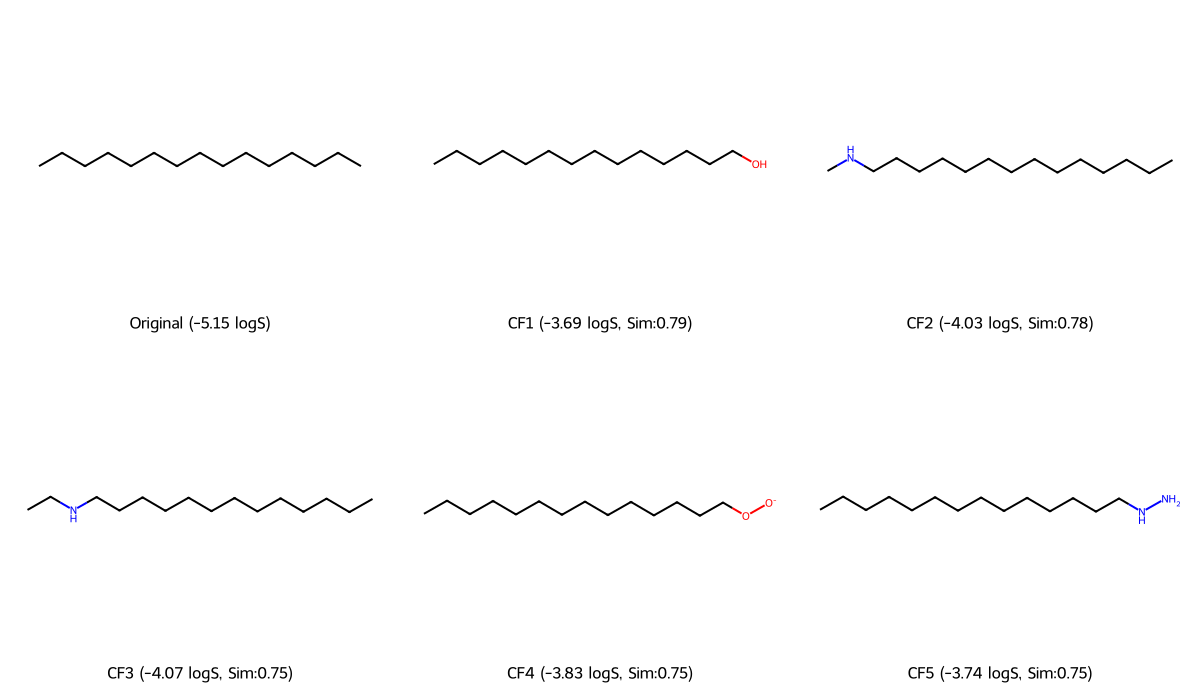


Summary Statistics:
  Total counterfactuals found: 10
  Average similarity: 0.739 +/- 0.028
  Prediction range: -4.074 to -3.554 logS
  Average change: +1.328 logS
  Solubility increases: 10 (avg: +1.33 logS)


In [12]:
from rdkit.Chem import Draw, Descriptors
from IPython.display import display


# --- Visualization Helper Functions ---

def display_counterfactual_grid(original_smiles: str,
                                original_pred: float,
                                counterfactuals: list,
                                max_display: int = 5,
                                mol_per_row: int = 3,
                                img_size: tuple = (400, 350)) -> None:
    """
    Display a grid of molecular structures comparing the original molecule with its counterfactuals.
    
    :param original_smiles: SMILES string of the original molecule.
    :param original_pred: Predicted value for the original molecule.
    :param counterfactuals: List of counterfactual objects (with .smiles, .yhat, .similarity attributes).
    :param max_display: Maximum number of counterfactuals to display.
    :param mol_per_row: Number of molecules per row in the grid.
    :param img_size: Size of each molecule image as (width, height).
    """
    original_mol = Chem.MolFromSmiles(original_smiles)
    
    mols_for_grid = [original_mol] if original_mol else []
    legends = [f'Original ({original_pred:.2f} logS)'] if original_mol else []
    
    for i, cf in enumerate(counterfactuals[:max_display], 1):
        cf_mol = Chem.MolFromSmiles(cf.smiles)
        if cf_mol:
            mols_for_grid.append(cf_mol)
            legends.append(f'CF{i} ({cf.yhat:.2f} logS, Sim:{cf.similarity:.2f})')
    
    if mols_for_grid:
        img = Draw.MolsToGridImage(
            mols_for_grid, 
            molsPerRow=mol_per_row, 
            subImgSize=img_size,
            legends=legends
        )
        display(img)


def print_counterfactual_summary(original_smiles: str,
                                  original_pred: float,
                                  counterfactuals: list,
                                  max_display: int = 5) -> None:
    """
    Print a detailed summary of counterfactual explanations.
    
    :param original_smiles: SMILES string of the original molecule.
    :param original_pred: Predicted value for the original molecule.
    :param counterfactuals: List of counterfactual objects.
    :param max_display: Maximum number of counterfactuals to summarize.
    """
    original_mol = Chem.MolFromSmiles(original_smiles)
    
    print('Original Molecule:')
    print(f'  SMILES: {original_smiles}')
    print(f'  Predicted solubility: {original_pred:.3f} logS')
    if original_mol:
        print(f'  Formula: {Chem.rdMolDescriptors.CalcMolFormula(original_mol)}')
        print(f'  Weight: {Descriptors.MolWt(original_mol):.2f}')
    
    print(f'\nTop Counterfactual Explanations:')
    print('-' * 70)
    
    for i, cf in enumerate(counterfactuals[:max_display], 1):
        cf_change = cf.prediction_change
        change_dir = "more soluble" if cf_change > 0 else "less soluble"
        
        print(f'\nCounterfactual {i}:')
        print(f'  SMILES: {cf.smiles}')
        print(f'  Solubility: {original_pred:.3f} -> {cf.yhat:.3f} logS (delta {cf_change:+.3f})')
        print(f'  Similarity: {cf.similarity:.3f}')
        
        cf_mol = Chem.MolFromSmiles(cf.smiles)
        if cf_mol and original_mol:
            print(f'  Formula: {Chem.rdMolDescriptors.CalcMolFormula(cf_mol)}')
            weight_change = Descriptors.MolWt(cf_mol) - Descriptors.MolWt(original_mol)
            print(f'  Weight: {Descriptors.MolWt(cf_mol):.1f} (delta {weight_change:+.1f})')
            print(f'  Interpretation: {change_dir}')


# --- Display MMACE Results ---

if len(counterfactuals) > 0:
    print('=' * 70)
    print('MMACE Counterfactual Analysis')
    print('=' * 70)
    
    print_counterfactual_summary(selected_molecule, selected_prediction, counterfactuals)
    
    print('\nMolecular Structures:')
    display_counterfactual_grid(selected_molecule, selected_prediction, counterfactuals)
    
    # Summary statistics
    similarities = [cf.similarity for cf in counterfactuals]
    predictions = [cf.yhat for cf in counterfactuals]
    changes = [cf.prediction_change for cf in counterfactuals]
    
    print('\nSummary Statistics:')
    print(f'  Total counterfactuals found: {len(counterfactuals)}')
    print(f'  Average similarity: {np.mean(similarities):.3f} +/- {np.std(similarities):.3f}')
    print(f'  Prediction range: {min(predictions):.3f} to {max(predictions):.3f} logS')
    print(f'  Average change: {np.mean(changes):+.3f} logS')
    
    increases = [c for c in changes if c > 0]
    decreases = [c for c in changes if c < 0]
    if increases:
        print(f'  Solubility increases: {len(increases)} (avg: +{np.mean(increases):.2f} logS)')
    if decreases:
        print(f'  Solubility decreases: {len(decreases)} (avg: {np.mean(decreases):.2f} logS)')

else:
    print('No counterfactual explanations found.')
    print('The molecule may be in a stable prediction region.')

**Interpreting MMACE Results.** The counterfactual explanations above show molecular variants that would significantly change the model's solubility prediction. Each counterfactual is ranked by its *structural similarity* to the original molecule &mdash; the most similar counterfactuals appear first. Key aspects to examine:

- **Prediction change (Δ logS)**: Positive values indicate the modification would increase predicted solubility; negative values indicate decreased solubility.
- **Similarity score**: Higher values (closer to 1.0) indicate counterfactuals that are structurally more similar to the original molecule.
- **Structural modifications**: Compare the molecular structures to identify which functional group changes or scaffold modifications drive the prediction differences.

The MMACE method explores a broad chemical space through random sampling, which means it may discover counterfactuals with multiple simultaneous modifications. This provides diverse suggestions but doesn't guarantee finding the *minimal* change needed to shift the prediction.

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 3.1** $\cdot$ Try generating counterfactual explanations for a highly soluble molecule (logS > -2) from the dataset. What structural changes does the model suggest would significantly decrease its solubility? Do these changes align with known structure-solubility relationships in medicinal chemistry?

</div>

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 3.2** $\cdot$ Modify the MMACE parameters (number of samples, preset settings) and observe how this affects the quality and diversity of counterfactual explanations. Try different `preset` values ('fast', 'medium', 'slow') and compare the results.

</div>

## **3.3** $\cdot$ 📚 *Graph-Edit Neighborhood Counterfactuals* (`vgd-counterfactuals`)

The second counterfactual method we'll explore takes a fundamentally different approach to generating molecular counterfactuals. While MMACE uses random sampling via the STONED algorithm to explore chemical space, the [vgd-counterfactuals](https://github.com/the16thpythonist/vgd_counterfactuals) library by [Teufel *et al.*](https://github.com/the16thpythonist/vgd_counterfactuals) employs **exhaustive enumeration** of all valid molecular modifications within a given edit distance.

**Core Methodology.** The vgd-counterfactuals approach works by:
1. **Exhaustive Neighborhood Generation**: Systematically generates *all* chemically valid 1-edit modifications of the input molecule (atom additions, bond additions/modifications, bond removals)
2. **Valence Constraint Enforcement**: Each modification respects chemical valence rules using RDKit's sanitization
3. **Model Evaluation**: Predicts properties for the entire neighborhood using the target model
4. **Distance Ranking**: Ranks counterfactuals by the magnitude of prediction change
5. **Selection**: Returns the top-k modifications with the largest prediction differences

**Key Advantages.** Unlike sampling-based methods, exhaustive enumeration *guarantees* finding the optimal counterfactual within the specified edit distance. For 1-edit neighborhoods, this approach will always find the single structural change that causes the maximum prediction shift &mdash; something that random sampling might miss.

**Trade-offs.** The exhaustive approach scales exponentially with edit distance. While 1-edit neighborhoods are computationally tractable (typically hundreds to thousands of neighbors), 2-edit neighborhoods can explode to hundreds of thousands of candidates. This makes the method most suitable for understanding minimal structural changes.

### Setting Up the Counterfactual Generator

To use the vgd-counterfactuals library, we define a wrapper function that generates all valid molecular modifications and evaluates them with our trained model. The library's `get_neighborhood` function enumerates chemically valid edits while respecting valence constraints.

**📝 Note.** The exhaustive enumeration approach scales exponentially with edit distance. While 1-edit neighborhoods are computationally tractable (typically hundreds to thousands of candidates), 2-edit neighborhoods can produce hundreds of thousands of molecules. For larger edit distances, consider using sampling-based methods like MMACE instead.

In [13]:
from vgd_counterfactuals.generate.molecules import get_neighborhood


def generate_exhaustive_counterfactuals(smiles: str, 
                                         model: SolubilityGNN, 
                                         k_results: int = 10,
                                         k_hops: int = 1,
                                         ) -> list[dict]:
    """
    Generate counterfactuals by exhaustively enumerating all valid k-edit modifications
    of a molecule and ranking them by the magnitude of prediction change.
    
    Unlike sampling-based methods, this approach guarantees finding the optimal counterfactual
    within the specified edit distance by evaluating every valid molecular modification.
    
    :param smiles: SMILES string of the target molecule.
    :param model: Trained SolubilityGNN model for predictions.
    :param k_results: Number of top counterfactuals to return.
    :param k_hops: Number of edit operations (1 = single modifications, 2 = two sequential edits).
    
    :returns: List of counterfactual dictionaries sorted by prediction change magnitude,
        each containing 'smiles', 'prediction', 'distance', 'modification_type', and index info.
    """
    # Get original prediction for comparison
    original_pred = model.predict_smiles(smiles)
    
    # Generate all valid k-edit neighbors using VGD's neighborhood function
    neighbors = get_neighborhood(smiles, k=k_hops)
    print(f'  Generated {len(neighbors)} valid {k_hops}-edit modifications')
    
    # Predict for all neighbors and compute prediction distances
    results = []
    for neighbor in neighbors:
        neighbor_smiles = neighbor['value']
        try:
            neighbor_pred = model.predict_smiles(neighbor_smiles)
            distance = abs(neighbor_pred - original_pred)
            
            results.append({
                'smiles': neighbor_smiles,
                'prediction': neighbor_pred,
                'distance': distance,
                'modification_type': neighbor['type'],
                'original_indices': neighbor.get('org', None),
                'modified_indices': neighbor.get('mod', None),
            })
        except Exception:
            # Skip molecules that cause prediction errors
            continue
    
    # Sort by distance (largest prediction change first) and return top k
    results = sorted(results, key=lambda x: x['distance'], reverse=True)
    return results[:k_results]

### Generating Exhaustive Counterfactuals

Now we can generate counterfactuals for the same target molecule we used with MMACE. The key difference is that this method will enumerate *all* valid 1-edit modifications and guarantee finding the optimal counterfactual &mdash; the single structural change that causes the maximum prediction shift.

In [14]:
# --- Generate counterfactuals using exhaustive enumeration ---

print(f'Generating exhaustive counterfactuals for: {TARGET_SMILES}')
print(f'Original prediction: {selected_prediction:.3f} logS')
print('Enumerating all valid 1-edit modifications...\n')

vgd_counterfactuals = generate_exhaustive_counterfactuals(
    smiles=TARGET_SMILES,
    model=model,
    k_results=10,
    k_hops=1,
)

print(f'\nGenerated {len(vgd_counterfactuals)} top counterfactuals')
if vgd_counterfactuals:
    print(f'  Largest prediction change: {vgd_counterfactuals[0]["distance"]:.3f} logS')
    print(f'  Smallest prediction change: {vgd_counterfactuals[-1]["distance"]:.3f} logS')

Generating exhaustive counterfactuals for: CCCCCCCCCCCCCCC
Original prediction: -5.149 logS
Enumerating all valid 1-edit modifications...



TypeError: get_neighborhood() got an unexpected keyword argument 'k'

In [ ]:
# --- Visualization Helper for VGD Counterfactuals ---

def display_vgd_counterfactual_grid(original_smiles: str,
                                     original_pred: float,
                                     counterfactuals: list[dict],
                                     max_display: int = 5,
                                     mol_per_row: int = 3,
                                     img_size: tuple = (400, 350)) -> None:
    """
    Display a grid of molecular structures for VGD-style counterfactuals (dict format).
    
    :param original_smiles: SMILES string of the original molecule.
    :param original_pred: Predicted value for the original molecule.
    :param counterfactuals: List of counterfactual dictionaries with 'smiles' and 'prediction' keys.
    :param max_display: Maximum number of counterfactuals to display.
    :param mol_per_row: Number of molecules per row in the grid.
    :param img_size: Size of each molecule image as (width, height).
    """
    original_mol = Chem.MolFromSmiles(original_smiles)
    
    mols_for_grid = [original_mol] if original_mol else []
    legends = [f'Original ({original_pred:.2f} logS)'] if original_mol else []
    
    for i, cf in enumerate(counterfactuals[:max_display], 1):
        cf_mol = Chem.MolFromSmiles(cf['smiles'])
        if cf_mol:
            cf_change = cf['prediction'] - original_pred
            mols_for_grid.append(cf_mol)
            legends.append(f'CF{i} ({cf["prediction"]:.2f} logS, d{cf_change:+.2f})')
    
    if mols_for_grid:
        img = Draw.MolsToGridImage(
            mols_for_grid, 
            molsPerRow=mol_per_row, 
            subImgSize=img_size,
            legends=legends
        )
        display(img)


# --- Display VGD Results ---

print('=' * 70)
print('VGD Exhaustive Counterfactual Analysis')
print('=' * 70)

original_mol = Chem.MolFromSmiles(TARGET_SMILES)

print('\nOriginal Molecule:')
print(f'  SMILES: {TARGET_SMILES}')
print(f'  Predicted solubility: {selected_prediction:.3f} logS')
if original_mol:
    print(f'  Formula: {Chem.rdMolDescriptors.CalcMolFormula(original_mol)}')
    print(f'  Atoms: {original_mol.GetNumAtoms()} | Bonds: {original_mol.GetNumBonds()}')

print(f'\nTop Counterfactuals (by prediction change):')
print('-' * 70)

for i, cf in enumerate(vgd_counterfactuals[:5], 1):
    cf_change = cf['prediction'] - selected_prediction
    change_dir = "more soluble" if cf_change > 0 else "less soluble"
    
    print(f'\nCounterfactual {i}:')
    print(f'  SMILES: {cf["smiles"]}')
    print(f'  Solubility: {selected_prediction:.3f} -> {cf["prediction"]:.3f} logS (delta {cf_change:+.3f})')
    print(f'  Modification type: {cf["modification_type"]}')
    
    cf_mol = Chem.MolFromSmiles(cf['smiles'])
    if cf_mol:
        print(f'  Formula: {Chem.rdMolDescriptors.CalcMolFormula(cf_mol)}')
        print(f'  Interpretation: {change_dir}')

# Display molecular structures
print('\nMolecular Structures:')
display_vgd_counterfactual_grid(TARGET_SMILES, selected_prediction, vgd_counterfactuals)

# Summary statistics
print('\nSummary Statistics:')
print(f'  Total counterfactuals: {len(vgd_counterfactuals)}')
distances = [cf['distance'] for cf in vgd_counterfactuals]
print(f'  Prediction change range: {min(distances):.3f} to {max(distances):.3f} logS')
print(f'  Average change: {np.mean(distances):.3f} +/- {np.std(distances):.3f} logS')

# Count modification types
mod_types = {}
for cf in vgd_counterfactuals:
    t = cf['modification_type']
    mod_types[t] = mod_types.get(t, 0) + 1
print(f'  Modification types: {mod_types}')

**Interpreting Exhaustive Enumeration Results.** Unlike MMACE, the exhaustive approach guarantees finding the *optimal* counterfactual within the specified edit distance. The counterfactuals are ranked by the *magnitude* of prediction change rather than similarity. Key aspects to examine:

- **Modification type**: Each counterfactual represents a single, specific molecular edit (e.g., atom addition, bond modification, atom replacement).
- **Prediction change**: The largest changes appear first, revealing which single modifications have the greatest impact on the model's predictions.
- **Chemical interpretability**: Since each counterfactual differs by exactly one edit, the structure-property relationship is immediately clear &mdash; "adding oxygen here increases solubility by X logS units."

This approach is particularly valuable for lead optimization, where medicinal chemists need to know the single most impactful modification to make.

<div style="background: #fff0c2; padding: 10px; border-style: solid; border-width: 1px; border-color: #dbad21; border-radius: 3px; color: black;">

**🛠️ Exercise 3.3** $\cdot$ The `get_neighborhood` function accepts an optional `k` parameter controlling the edit distance. Modify the `generate_exhaustive_counterfactuals` function to use a 2-hop neighborhood (`k=2`) and compare the resulting counterfactuals to the 1-edit results. What structural changes become possible with two sequential edits?

</div>

### Comparing MMACE vs Exhaustive Enumeration

Now let's directly compare the counterfactuals generated by both methods. This comparison highlights the fundamental trade-off between sampling-based and exhaustive approaches.

In [ ]:
# --- Compare MMACE and VGD counterfactuals ---

print('=' * 70)
print('Comparison: MMACE (Sampling) vs VGD (Exhaustive)')
print('=' * 70)

# Get best counterfactual from each method
if counterfactuals:
    mmace_best = counterfactuals[0]
    mmace_change = mmace_best.prediction_change
    print(f'\nMMACE (STONED sampling):')
    print(f'  Best counterfactual: {mmace_best.smiles}')
    print(f'  Prediction change: delta {mmace_change:+.3f} logS')
    print(f'  Similarity: {mmace_best.similarity:.3f}')

if vgd_counterfactuals:
    vgd_best = vgd_counterfactuals[0]
    vgd_change = vgd_best['prediction'] - selected_prediction
    print(f'\nVGD (Exhaustive enumeration):')
    print(f'  Best counterfactual: {vgd_best["smiles"]}')
    print(f'  Prediction change: delta {vgd_change:+.3f} logS')
    print(f'  Modification type: {vgd_best["modification_type"]}')

# Visual comparison of top counterfactuals from both methods
print('\nSide-by-Side Comparison:')
comparison_mols = []
comparison_legends = []

# Original
if original_mol:
    comparison_mols.append(original_mol)
    comparison_legends.append(f'Original\n{selected_prediction:.2f} logS')

# Best MMACE
if counterfactuals:
    mmace_mol = Chem.MolFromSmiles(mmace_best.smiles)
    if mmace_mol:
        comparison_mols.append(mmace_mol)
        comparison_legends.append(f'MMACE Best\n{mmace_best.yhat:.2f} logS')

# Best VGD
if vgd_counterfactuals:
    vgd_mol = Chem.MolFromSmiles(vgd_best['smiles'])
    if vgd_mol:
        comparison_mols.append(vgd_mol)
        comparison_legends.append(f'VGD Best\n{vgd_best["prediction"]:.2f} logS')

if comparison_mols:
    img = Draw.MolsToGridImage(
        comparison_mols, 
        molsPerRow=3, 
        subImgSize=(400, 350),
        legends=comparison_legends
    )
    display(img)

# Summary table
print('\nMethod Comparison Summary:')
print('-' * 70)
print(f'{"Method":<25} {"Approach":<20} {"Best d logS":<15} {"Guarantee"}')
print('-' * 70)
if counterfactuals:
    print(f'{"MMACE":<25} {"Random sampling":<20} {mmace_change:+.3f}{"":>10} {"Probabilistic"}')
if vgd_counterfactuals:
    print(f'{"VGD":<25} {"Exhaustive enum.":<20} {vgd_change:+.3f}{"":>10} {"Optimal in 1-edit"}')

**Method Comparison Insights.** The two counterfactual methods presented in this tutorial represent complementary approaches that differ fundamentally in their search strategy. MMACE explores chemical space *broadly* through random sampling via the STONED algorithm, generating diverse molecular variants that may differ from the original by multiple structural modifications. From this broad sample, counterfactuals are then ranked by their *similarity* to the original molecule, prioritizing those that achieve the desired prediction change while remaining structurally close. In contrast, the exhaustive enumeration approach enforces *strict locality* by considering only molecules that differ by exactly one edit operation. Within this constrained neighborhood, counterfactuals are ranked by the *magnitude of prediction change*, identifying which single modification has the largest impact on the model's output.

This difference in search strategy leads to distinct trade-offs. The sampling-based approach can discover counterfactuals that require multiple simultaneous changes &mdash; modifications that might never be found through single-edit enumeration alone. However, because STONED samples randomly, there is no guarantee of finding the optimal counterfactual even within the sampled space. The exhaustive approach, conversely, guarantees finding the single most impactful modification within its edit distance, but this guarantee comes at a computational cost that scales exponentially with the number of allowed edits.

In practice, the choice between these methods may depend on the specific goals of the analysis. When the objective is to understand which *minimal* structural change would most affect a prediction &mdash; as might be the case in lead optimization where a medicinal chemist seeks the single most promising modification &mdash; exhaustive enumeration tends to provide more directly actionable insights. The explicit "change this atom to that" interpretation is immediately clear. On the other hand, when exploring broader design possibilities or when the interesting counterfactuals might require coordinated changes across multiple positions in the molecule, the sampling-based approach may reveal alternatives that strict locality constraints would miss.

It is worth noting that these methods often identify similar structural features as relevant to the predicted property, even if they present this information differently. Both approaches tend to highlight the importance of polar functional groups for solubility, for instance, but exhaustive enumeration might show "adding a hydroxyl group here increases solubility" while MMACE might present a more distant analog that happens to contain additional polar groups. The two perspectives can therefore be seen as complementary views on the same underlying structure-property relationships learned by the model.